# **CELL 1: ENVIRONMENT SETUP & DEPENDENCIESA**

PURPOSE: Install required packages and import libraries.
This cell only needs to be run once at the beginning

In [62]:
# ============================================================================
# CELL 1: ENVIRONMENT SETUP & DEPENDENCIESA
# ============================================================================
# PURPOSE: Install required packages and import libraries
# This cell only needs to be run once at the beginning

!pip install -q torch transformers datasets tqdm matplotlib numpy pandas scikit-learn sentence-transformers ipywidgets seaborn wordcloud

# Import all necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    AutoModelForSequenceClassification
)
from datasets import load_dataset
import math
from collections import Counter
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings

warnings.filterwarnings('ignore')

# Check if GPU is available (for faster processing)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   Using CPU (slower but works)")

print("\n📚 All libraries imported successfully!")

✅ Using device: cpu
   Using CPU (slower but works)

📚 All libraries imported successfully!


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [61]:
#@title # 2. LOAD MS MARCO DATASET (VIA HUGGINGFACE)
#@markdown This uses the official HuggingFace datasets hub - no broken links!
#@markdown
#@markdown **Official Documentation**:
#@markdown - Dataset Card: https://huggingface.co/datasets/ms_marco
#@markdown - MS MARCO Official: https://microsoft.github.io/msmarco/

print("="*60)
print("LOADING MS MARCO DATASET FROM HUGGINGFACE")
print("="*60)

# Load the MS MARCO passage ranking dataset from HuggingFace
# This is the official dataset - same as the Microsoft original
print("\n📥 Downloading MS MARCO dataset (this may take a few minutes)...")

# Load a small subset for demonstration (use 'train' for full dataset)
# 'ms_marco' has two configurations: 'v1.1' and 'v2.1'
dataset = load_dataset("ms_marco", "v1.1", split="train", streaming=True)

# Take a small sample for demonstration
print("📊 Taking sample of 2000 examples for training...")
train_samples_raw = [] # Renamed for clarity
for i, example in enumerate(dataset):
    if i >= 2000:  # Use 2000 samples for faster training
        break
    train_samples_raw.append(example)

print(f"✅ Loaded {len(train_samples_raw)} training examples")

# Display a sample to understand the data format
print("\n📋 Sample data format:")
sample = train_samples_raw[0]
print(f"   Query ID: {sample['query_id']}")
print(f"   Query: {sample['query']}")
print(f"   Passages: {len(sample['passages'])} passages per query")
print(f"   Selected passage: {sample['passages']['is_selected'][0]}")
print(f"   Answers: {sample['answers']}")

# Prepare training triples (query, positive passage, negative passage)
# MS MARCO provides 10 passages per query, with 'is_selected' indicating relevance
print("\n🔧 Preparing training triples...")
train_triples_raw = [] # Renamed for clarity
corpus_set = set() # To collect all unique passages

for example in tqdm(train_samples_raw):
    query = example['query']
    passages = example['passages']

    # Find positive passages (is_selected = 1)
    positive_passages = []
    negative_passages = []

    for i, is_selected in enumerate(passages['is_selected']):
        passage_text = passages['passage_text'][i]
        corpus_set.add(passage_text)
        if is_selected == 1:
            positive_passages.append(passage_text)
        else:
            negative_passages.append(passage_text)

    # Create triples (query, positive, negative)
    if positive_passages and negative_passages:
        train_triples_raw.append({
            'query': query,
            'positive': positive_passages[0],  # Take first positive
            'negative': negative_passages[0]   # Take first negative
        })


print(f"✅ Created {len(train_triples_raw)} training triples")

# Store all processed data in a global dictionary for easy access
ms_marco_data = {
    'train_samples_raw': train_samples_raw,
    'train_triples_raw': train_triples_raw,
    'corpus_set': corpus_set
}

LOADING MS MARCO DATASET FROM HUGGINGFACE

📥 Downloading MS MARCO dataset (this may take a few minutes)...
📊 Taking sample of 2000 examples for training...
✅ Loaded 2000 training examples

📋 Sample data format:
   Query ID: 19699
   Query: what is rba
   Passages: 3 passages per query
   Selected passage: 0
   Answers: ['Results-Based Accountability is a disciplined way of thinking and taking action that communities can use to improve the lives of children, youth, families, adults and the community as a whole.']

🔧 Preparing training triples...


100%|██████████| 2000/2000 [00:00<00:00, 60341.88it/s]

✅ Created 1937 training triples


# **CELL 2: EXPLORATORY DATA ANALYSIS (EDA) - UNDERSTAND THE DATASET**

PURPOSE: Analyze the MS MARCO dataset structure and statistics.
This helps us understand what data we're working with


EXPLORATORY DATA ANALYSIS (EDA) - MS MARCO DATASET

📥 Using previously loaded dataset sample for analysis...

✅ Loaded 2000 samples for analysis

--------------------------------------------------
📊 1. QUERY ANALYSIS (Questions)
--------------------------------------------------
   Total queries analyzed: 2000
   Average query length: 6.1 words
   Shortest query: 2 words
   Longest query: 18 words
   Query length std dev: 2.4


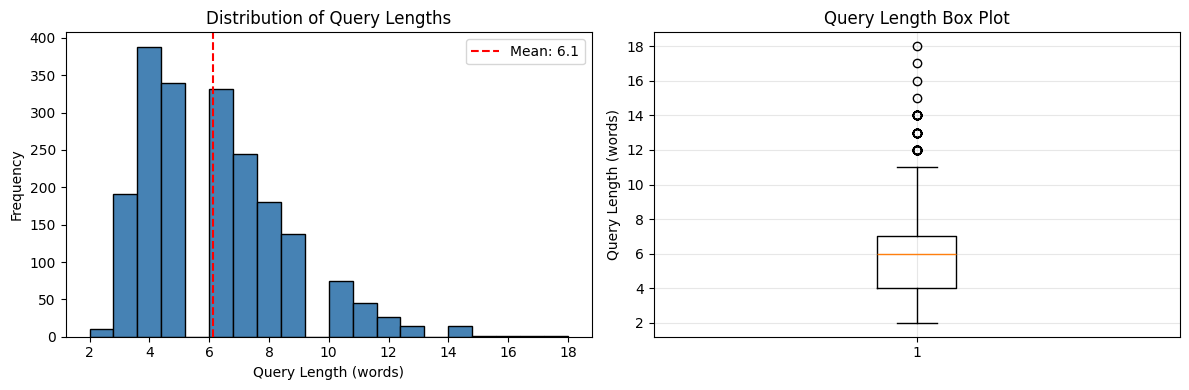


📝 Sample Queries (First 5):
   1. what is rba
   2. was ronald reagan a democrat
   3. how long do you need for sydney and surrounding areas
   4. price to install tile in shower
   5. why conversion observed in body

--------------------------------------------------
📄 2. PASSAGE ANALYSIS
--------------------------------------------------
   Total passages analyzed: 16511
   Average passage length: 71.1 words
   Shortest passage: 9 words
   Longest passage: 191 words
   Passages per query: 8.3


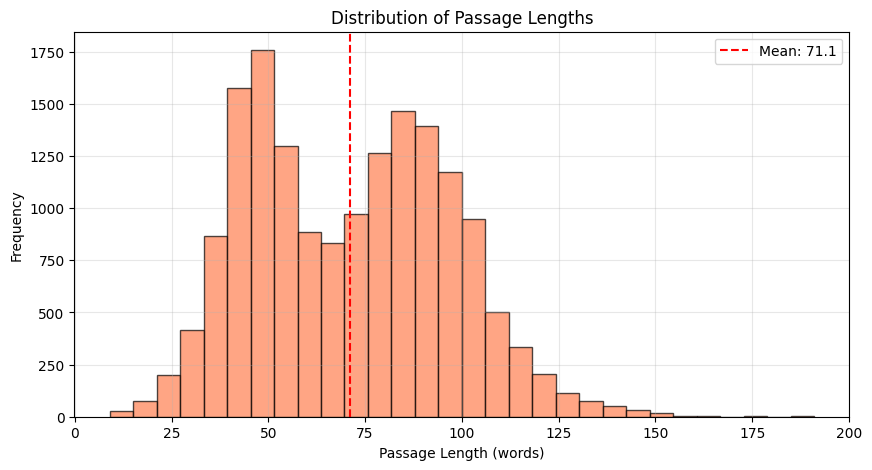


--------------------------------------------------
🎯 3. RELEVANCE ANALYSIS
--------------------------------------------------
   Average relevant passages per query: 1.08
   Queries with zero relevant passages: 63
   Queries with at least one relevant passage: 1937


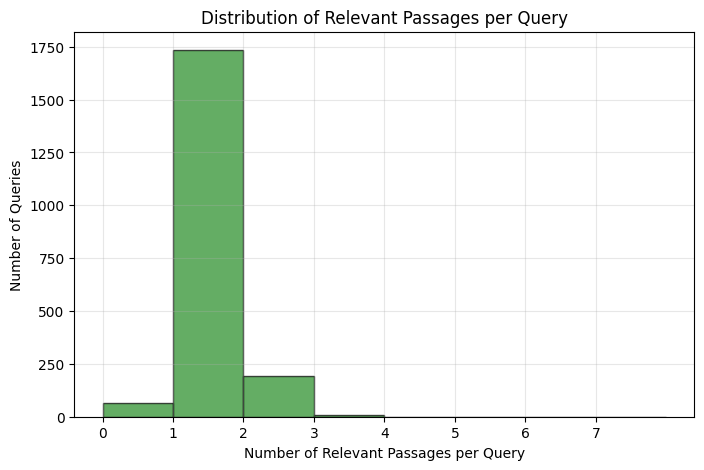


--------------------------------------------------
📖 4. VOCABULARY ANALYSIS
--------------------------------------------------
   Unique words in queries: 3,722
   Unique words in passages: 12,790
   Vocabulary overlap: 1,745

🔤 Most common words in queries:
   'what': 815 occurrences
   'is': 676 occurrences
   'the': 421 occurrences
   'a': 368 occurrences
   'of': 350 occurrences
   'how': 327 occurrences
   'does': 260 occurrences
   'to': 248 occurrences
   'in': 242 occurrences
   'for': 205 occurrences

✅ EDA Complete! Dataset insights ready for model building


In [65]:
# ============================================================================
# CELL 2: EXPLORATORY DATA ANALYSIS (EDA) - UNDERSTAND THE DATASET
# ============================================================================
# PURPOSE: Analyze the MS MARCO dataset structure and statistics
# This helps us understand what data we're working with

print("="*70)
print("EXPLORATORY DATA ANALYSIS (EDA) - MS MARCO DATASET")
print("="*70)

# Load a small sample of the dataset for analysis
print("\n📥 Using previously loaded dataset sample for analysis...")

# Collect sample data for analysis from the globally stored data
sample_data_eda = ms_marco_data['train_samples_raw'] # Renamed for clarity

print(f"\n✅ Loaded {len(sample_data_eda)} samples for analysis")

# ============================================================================
# 2.1 Analyze Query (Question) Statistics
# ============================================================================
print("\n" + "-"*50)
print("📊 1. QUERY ANALYSIS (Questions)")
print("-"*50)

# Extract all queries
queries = [ex['query'] for ex in sample_data_eda]
query_lengths = [len(q.split()) for q in queries]

print(f"   Total queries analyzed: {len(queries)}")
print(f"   Average query length: {np.mean(query_lengths):.1f} words")
print(f"   Shortest query: {min(query_lengths)} words")
print(f"   Longest query: {max(query_lengths)} words")
print(f"   Query length std dev: {np.std(query_lengths):.1f}")

# Plot query length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(query_lengths, bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Query Length (words)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Query Lengths')
axes[0].axvline(np.mean(query_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(query_lengths):.1f}')
axes[0].legend()

# Box plot
axes[1].boxplot(query_lengths, vert=True)
axes[1].set_ylabel('Query Length (words)')
axes[1].set_title('Query Length Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sample queries
print("\n📝 Sample Queries (First 5):")
for i, q in enumerate(queries[:5], 1):
    print(f"   {i}. {q}")

# ============================================================================
# 2.2 Analyze Passage Statistics
# ============================================================================
print("\n" + "-"*50)
print("📄 2. PASSAGE ANALYSIS")
print("-"*50)

# Extract all passages
all_passages = []
for ex in sample_data_eda:
    for passage in ex['passages']['passage_text']:
        all_passages.append(passage)

passage_lengths = [len(p.split()) for p in all_passages]

print(f"   Total passages analyzed: {len(all_passages)}")
print(f"   Average passage length: {np.mean(passage_lengths):.1f} words")
print(f"   Shortest passage: {min(passage_lengths)} words")
print(f"   Longest passage: {max(passage_lengths)} words")
print(f"   Passages per query: {len(all_passages)/len(sample_data_eda):.1f}")

# Plot passage length distribution
plt.figure(figsize=(10, 5))
plt.hist(passage_lengths, bins=30, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Passage Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Passage Lengths')
plt.axvline(np.mean(passage_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(passage_lengths):.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================================
# 2.3 Analyze Relevance Distribution
# ============================================================================
print("\n" + "-"*50)
print("🎯 3. RELEVANCE ANALYSIS")
print("-"*50)

# Count relevant vs irrelevant passages per query
relevance_counts = []
for ex in sample_data_eda:
    relevant = sum(ex['passages']['is_selected'])
    total = len(ex['passages']['is_selected'])
    relevance_counts.append(relevant)

print(f"   Average relevant passages per query: {np.mean(relevance_counts):.2f}")
print(f"   Queries with zero relevant passages: {sum(1 for r in relevance_counts if r == 0)}")
print(f"   Queries with at least one relevant passage: {sum(1 for r in relevance_counts if r > 0)}")

# Plot relevance distribution
plt.figure(figsize=(8, 5))
plt.hist(relevance_counts, bins=range(0, max(relevance_counts)+2), color='forestgreen', edgecolor='black', alpha=0.7)
plt.xlabel('Number of Relevant Passages per Query')
plt.ylabel('Number of Queries')
plt.title('Distribution of Relevant Passages per Query')
plt.xticks(range(0, max(relevance_counts)+1))
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================================
# 2.4 Vocabulary Analysis
# ============================================================================
print("\n" + "-"*50)
print("📖 4. VOCABULARY ANALYSIS")
print("-"*50)

# Build vocabulary from queries and passages
all_query_words = ' '.join(queries).lower().split()
all_passage_words = ' '.join(all_passages[:1000]).lower().split() # Limit for speed

unique_query_words = set(all_query_words)
unique_passage_words = set(all_passage_words)

print(f"   Unique words in queries: {len(unique_query_words):,}")
print(f"   Unique words in passages: {len(unique_passage_words):,}")
print(f"   Vocabulary overlap: {len(unique_query_words & unique_passage_words):,}")

# Most common words in queries
query_word_freq = Counter(all_query_words)
print("\n🔤 Most common words in queries:")
for word, freq in query_word_freq.most_common(10):
    print(f"   '{word}': {freq} occurrences")

print("\n" + "="*70)
print("✅ EDA Complete! Dataset insights ready for model building")
print("="*70)

### **2.4.1 Top 10 Most Frequent Words in Queries**

The following table shows the top 10 most common words across all sampled queries.

In [ ]:
# Create a DataFrame for the top 10 words
top_10_words = query_word_freq.most_common(10)
words_df = pd.DataFrame(top_10_words, columns=['Word', 'Frequency'])

# Display the table
display(words_df)

,Word,Frequency
0,what,213
1,is,177
2,the,111
3,a,107
4,of,87
5,how,84
6,in,65
7,does,65
8,to,60
9,for,46


### **2.6 Extended Exploratory Data Analysis**

This section provides deeper insights into text distributions, TF-IDF keywords, and bigram patterns across queries and passages.

EXTENDED EXPLORATORY DATA ANALYSIS (REFINED)


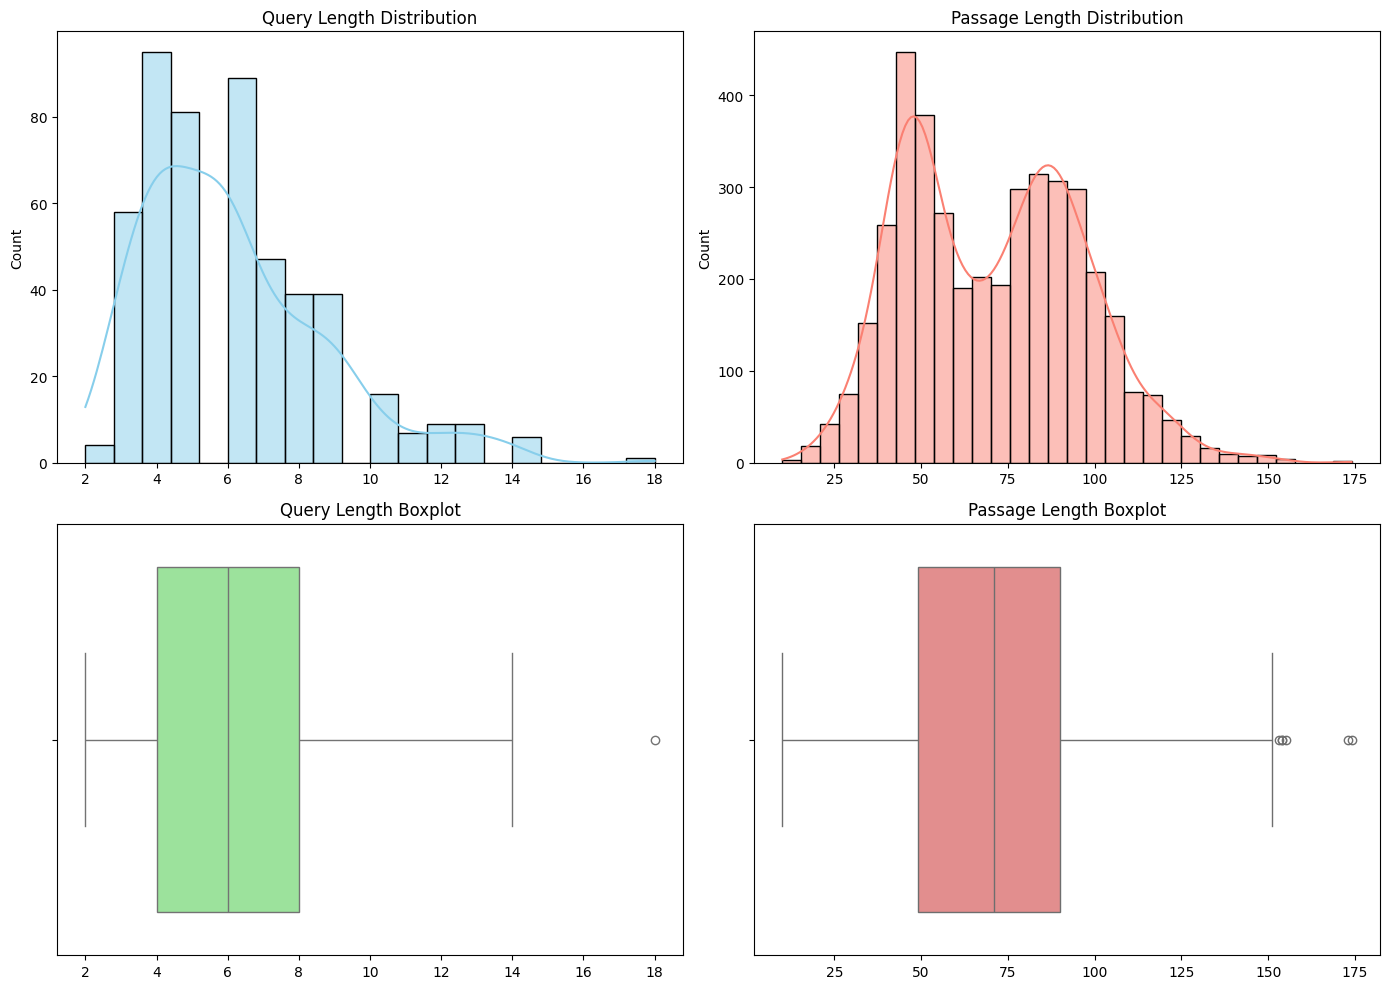

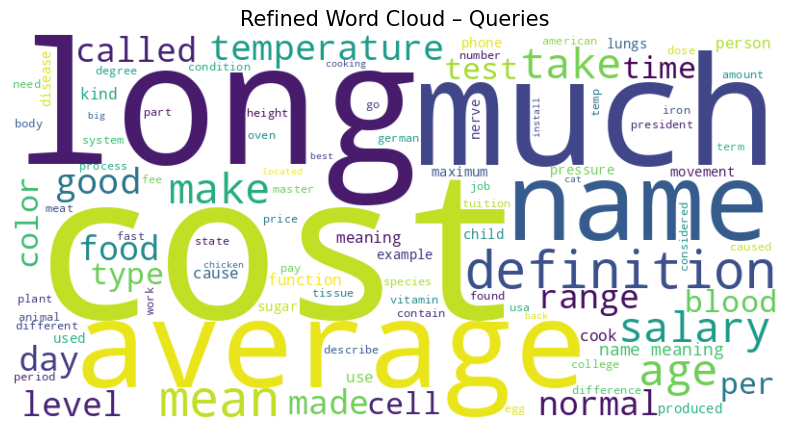

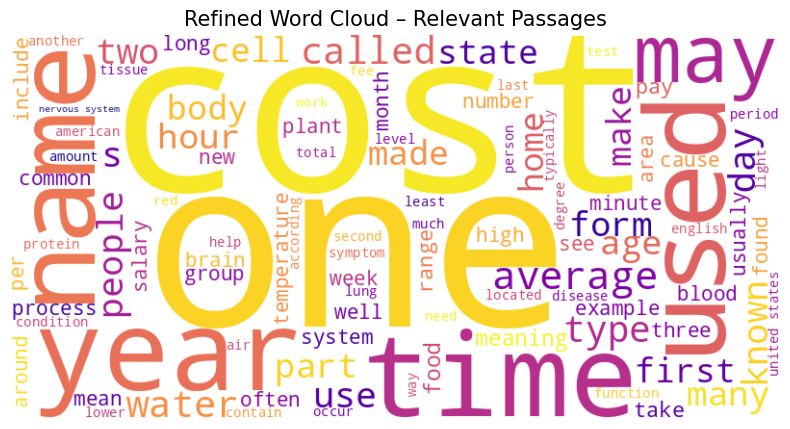


⌖ Top TF‑IDF keywords in queries:
   does: 49.6608
   cost: 27.6118
   long: 20.7608
   average: 14.6175
   definition: 14.0000
   meaning: 11.0000
   mean: 9.7157
   salary: 8.1013
   age: 6.9997
   temperature: 6.9752
   good: 6.7892
   called: 6.3960
   day: 6.0715
   time: 5.4322
   normal: 5.1636


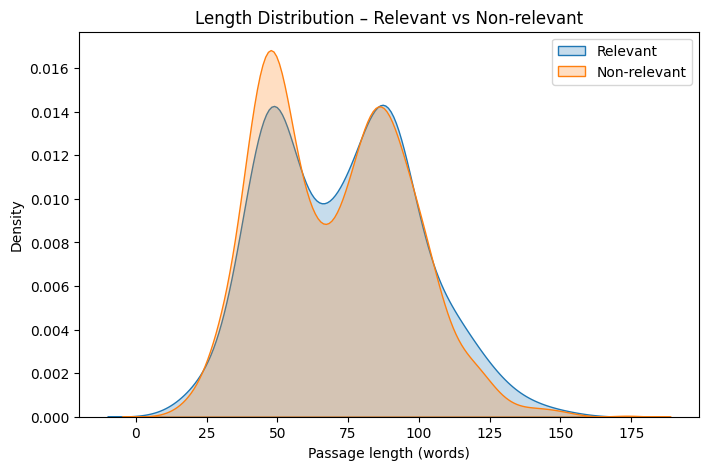

In [ ]:
print("="*70)
print("EXTENDED EXPLORATORY DATA ANALYSIS (REFINED)")
print("="*70)

# Load a small sample (streaming)
dataset = load_dataset("ms_marco", "v1.1", split="train", streaming=True)

sample_data = []
for i, ex in enumerate(dataset):
    if i >= 500: break
    sample_data.append(ex)

queries = [ex['query'] for ex in sample_data]
all_passages = []
relevant_passages = []
for ex in sample_data:
    for j, sel in enumerate(ex['passages']['is_selected']):
        text = ex['passages']['passage_text'][j]
        all_passages.append(text)
        if sel == 1:
            relevant_passages.append(text)

# 1. Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
query_len = [len(q.split()) for q in queries]
sns.histplot(query_len, bins=20, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Query Length Distribution')

passage_len = [len(p.split()) for p in all_passages]
sns.histplot(passage_len, bins=30, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Passage Length Distribution')

sns.boxplot(x=query_len, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Query Length Boxplot')
sns.boxplot(x=passage_len, ax=axes[1,1], color='lightcoral')
axes[1,1].set_title('Passage Length Boxplot')
plt.tight_layout()
plt.show()

# 2. Refined Word Clouds (Filtering Stopwords)
from wordcloud import STOPWORDS

custom_stopwords = set(STOPWORDS).union({"will", "is", "the", "a", "of", "what", "how", "does"})

def plot_cloud(text, title, cmap):
    wc = WordCloud(width=800, height=400, background_color='white',
                   stopwords=custom_stopwords, colormap=cmap, max_words=100).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=15)
    plt.show()

plot_cloud(' '.join(queries).lower(), 'Refined Word Cloud – Queries', 'viridis')
plot_cloud(' '.join(relevant_passages).lower(), 'Refined Word Cloud – Relevant Passages', 'plasma')

# 3. TF-IDF Top keywords
vectorizer = TfidfVectorizer(max_features=30, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(queries)
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.sum(axis=0).A1
top_keywords = sorted(zip(feature_names, tfidf_scores), key=lambda x: x[1], reverse=True)[:15]
print("\n⌖ Top TF‑IDF keywords in queries:")
for word, score in top_keywords:
    print(f"   {word}: {score:.4f}")

# 4. Passage length: relevant vs non-relevant
rel_lengths = []
nonrel_lengths = []
for ex in sample_data:
    for j, sel in enumerate(ex['passages']['is_selected']):
        length = len(ex['passages']['passage_text'][j].split())
        if sel == 1:
            rel_lengths.append(length)
        else:
            nonrel_lengths.append(length)

plt.figure(figsize=(8,5))
sns.kdeplot(rel_lengths, label='Relevant', fill=True)
sns.kdeplot(nonrel_lengths, label='Non-relevant', fill=True)
plt.xlabel('Passage length (words)')
plt.title('Length Distribution – Relevant vs Non-relevant')
plt.legend()
plt.show()

### **2.6.1 Word Clouds of Length Distributions**
In this view, larger numbers represent lengths that occur more frequently in the dataset.

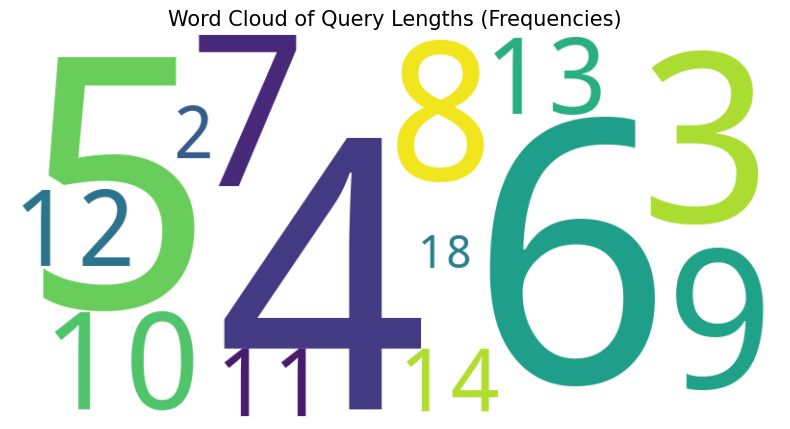

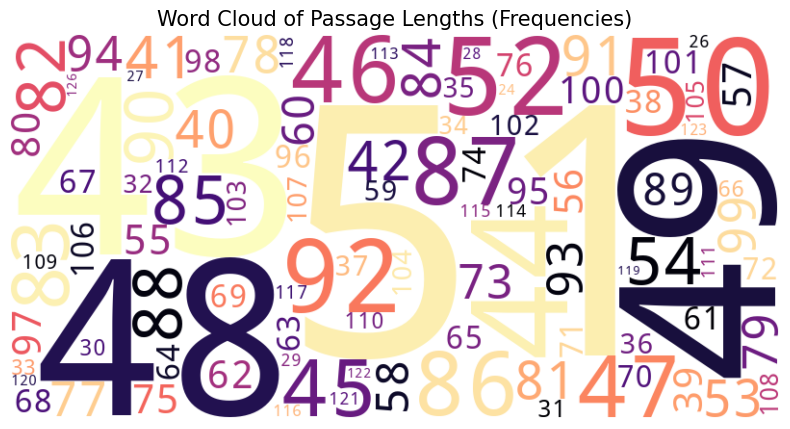

In [ ]:
def plot_length_cloud(lengths, title, cmap):
    # Count the frequency of each length
    length_counts = Counter(lengths)
    # Convert numeric keys to strings for the word cloud dictionary
    freq_dict = {str(k): v for k, v in length_counts.items()}

    # Generate word cloud from frequencies directly to avoid text filtering
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=15)
    plt.show()

# Generate clouds for Query and Passage lengths
# Using variables query_len and passage_len from the EDA cell
plot_length_cloud(query_len, 'Word Cloud of Query Lengths (Frequencies)', 'viridis')
plot_length_cloud(passage_len, 'Word Cloud of Passage Lengths (Frequencies)', 'magma')

### **2.6.2 Statistical Word Clouds of Lengths**
These visualizations treat each length value as a unique 'term', where the size of the number corresponds to how often that specific word count occurs in the dataset.

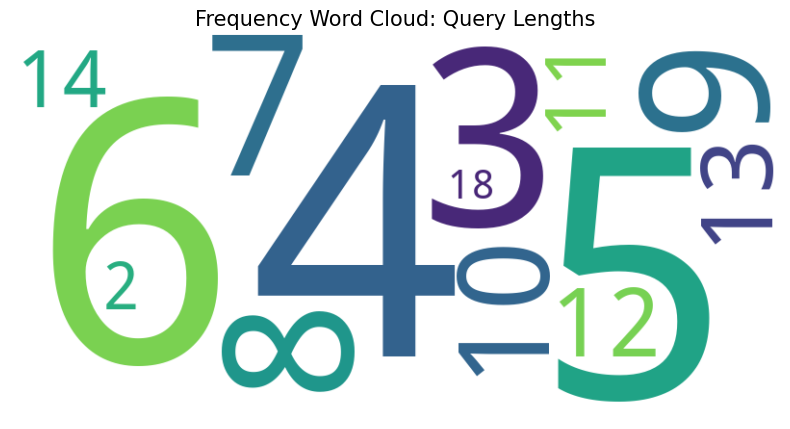

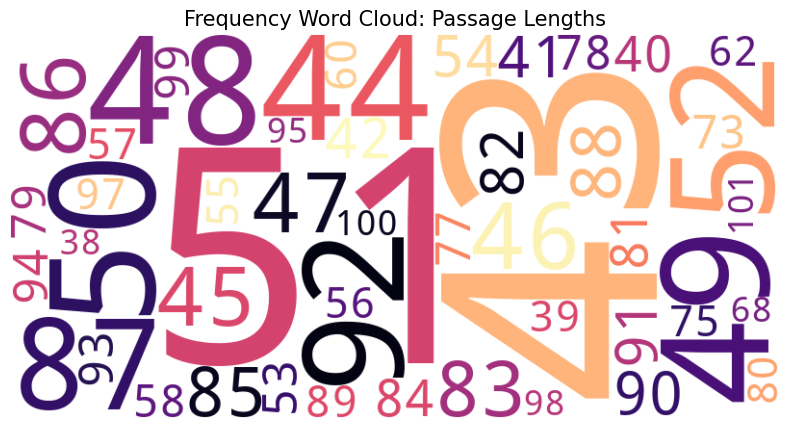

In [ ]:
def plot_freq_cloud(lengths, title, cmap):
    # Count occurrences of each length
    freqs = Counter(lengths)
    # Map lengths to strings so WordCloud can process them as tokens
    freq_dict = {str(k): v for k, v in freqs.items()}

    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=50).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=15)
    plt.show()

# Generate length frequency clouds
plot_freq_cloud(query_len, 'Frequency Word Cloud: Query Lengths', 'viridis')
plot_freq_cloud(passage_len, 'Frequency Word Cloud: Passage Lengths', 'magma')

# **CELL 3: BUILD TRAINING DATA FOR RE-RANKER**

PURPOSE: Prepare training triples (query, positive passage, negative passage)
This is the data format needed for training the neural re-ranker

BUILDING TRAINING DATA FOR NEURAL RE-RANKER

📥 Using previously loaded training data...

✅ Training Data Summary:
   Total training triples: 1937
   Unique passages in corpus: 16,433
   Sample triple:
   - Query: what is rba...
   - Positive: Results-Based Accountability® (also known as RBA) is a disciplined way of thinking and taking action...
   - Negative: Since 2007, the RBA's outstanding reputation has been affected by the 'Securency' or NPA scandal. Th...

📊 Training Data Statistics:
   Average query length: 6.1 words
   Average positive passage length: 72.0 words
   Average negative passage length: 70.0 words


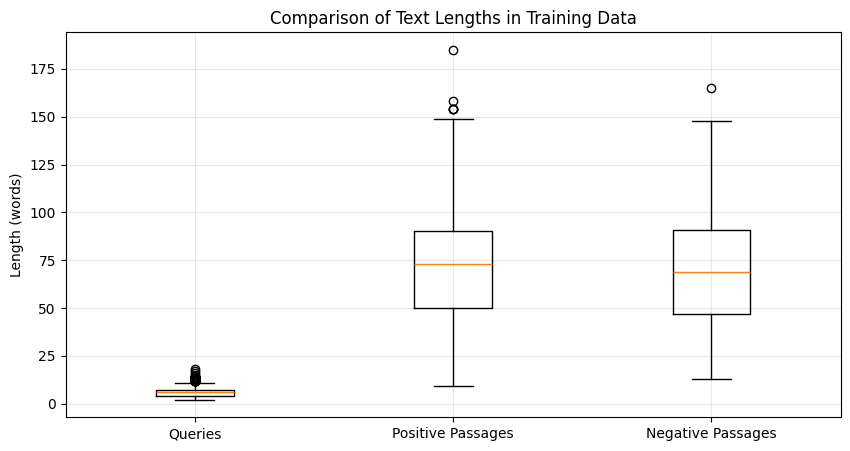

In [64]:
# ============================================================================
# CELL 3: BUILD TRAINING DATA FOR RE-RANKER
# ============================================================================
# PURPOSE: Prepare training triples (query, positive passage, negative passage)
# This is the data format needed for training the neural re-ranker

print("="*70)
print("BUILDING TRAINING DATA FOR NEURAL RE-RANKER")
print("="*70)

# Use previously loaded training data
print("\n📥 Using previously loaded training data...")
train_triples = ms_marco_data['train_triples_raw']
corpus_set = ms_marco_data['corpus_set'] # Get corpus_set from global

# Convert corpus set to list for indexing
corpus_list = list(corpus_set)

print(f"\n✅ Training Data Summary:")
print(f"   Total training triples: {len(train_triples)}")
print(f"   Unique passages in corpus: {len(corpus_list):,}")
print(f"   Sample triple:")
print(f"   - Query: {train_triples[0]['query'][:100]}...")
print(f"   - Positive: {train_triples[0]['positive'][:100]}...")
print(f"   - Negative: {train_triples[0]['negative'][:100]}...")

# ============================================================================
# Statistics about training data
# ============================================================================
print("\n📊 Training Data Statistics:")
query_lengths_train = [len(t['query'].split()) for t in train_triples]
pos_lengths = [len(t['positive'].split()) for t in train_triples]
neg_lengths = [len(t['negative'].split()) for t in train_triples]

print(f"   Average query length: {np.mean(query_lengths_train):.1f} words")
print(f"   Average positive passage length: {np.mean(pos_lengths):.1f} words")
print(f"   Average negative passage length: {np.mean(neg_lengths):.1f} words")

# Visualize length differences
plt.figure(figsize=(10, 5))
plt.boxplot([query_lengths_train, pos_lengths, neg_lengths], labels=['Queries', 'Positive Passages', 'Negative Passages'])
plt.ylabel('Length (words)')
plt.title('Comparison of Text Lengths in Training Data')
plt.grid(True, alpha=0.3)
plt.show()

# **CELL 4: SIMPLE TOKENIZER IMPLEMENTATION**

PURPOSE: Create a word-level tokenizer for text processing
This converts text to numbers that the neural network can understand

In [ ]:
# ============================================================================
# CELL 4: SIMPLE TOKENIZER IMPLEMENTATION
# ============================================================================
# PURPOSE: Create a word-level tokenizer for text processing
# This converts text to numbers that the neural network can understand

class SimpleTokenizer:
    """
    A simple word-level tokenizer for text.

    How it works:
    1. Build vocabulary from training texts (most common words)
    2. Convert text to list of integer IDs
    3. Special tokens: <PAD>=0 (padding), <UNK>=1 (unknown word)
    """

    def __init__(self, max_vocab=10000):
        """
        Initialize tokenizer.

        Args:
            max_vocab: Maximum vocabulary size (keep most frequent words)
        """
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}  # Special tokens
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.max_vocab = max_vocab

    def build_vocab(self, texts):
        """
        Build vocabulary from list of texts.

        Args:
            texts: List of strings to build vocabulary from
        """
        print("   Building vocabulary...")
        word_counts = Counter()

        # Count word frequencies
        for text in texts:
            words = text.lower().split()
            word_counts.update(words)

        # Keep only most frequent words
        most_common = word_counts.most_common(self.max_vocab - 2)

        for word, count in most_common:
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

        print(f"   Vocabulary size: {len(self.word2idx)} words")
        print(f"   Most common word: '{most_common[0][0]}' ({most_common[0][1]} occurrences)")

    def encode(self, text, max_len=20):
        """
        Convert text to list of token IDs.

        Args:
            text: Input string
            max_len: Maximum sequence length (truncate if longer)

        Returns:
            List of integers (token IDs)
        """
        words = text.lower().split()[:max_len]
        return [self.word2idx.get(word, 1) for word in words]  # 1 = <UNK>

    def decode(self, ids):
        """
        Convert token IDs back to text (for debugging).

        Args:
            ids: List of token IDs

        Returns:
            String representation
        """
        words = [self.idx2word.get(idx, '<UNK>') for idx in ids]
        return ' '.join(words)

# Test the tokenizer
print("="*70)
print("TESTING SIMPLE TOKENIZER")
print("="*70)

# Create and train tokenizer
tokenizer = SimpleTokenizer(max_vocab=5000)

# Collect training texts
training_texts = []
for triple in train_triples[:500]:
    training_texts.append(triple['query'])
    training_texts.append(triple['positive'])
    training_texts.append(triple['negative'])

tokenizer.build_vocab(training_texts)

# Test encoding/decoding
test_text = "what is machine learning"
encoded = tokenizer.encode(test_text, max_len=10)
decoded = tokenizer.decode(encoded)

print(f"\n📝 Tokenizer Test:")
print(f"   Original: {test_text}")
print(f"   Encoded: {encoded}")
print(f"   Decoded: {decoded}")

TESTING SIMPLE TOKENIZER
   Building vocabulary...
   Vocabulary size: 5000 words
   Most common word: 'the' (4459 occurrences)

📝 Tokenizer Test:
   Original: what is machine learning
   Encoded: [25, 6, 1, 1]
   Decoded: what is <UNK> <UNK>


# **CELL 5: KNRM MODEL - NEURAL RE-RANKER FROM SCRATCH**

PURPOSE: Implement KNRM (Kernel-based Neural Ranking Model)
This is the core neural re-ranking model for Part 1

In [ ]:
# ============================================================================
# CELL 5: KNRM MODEL - NEURAL RE-RANKER FROM SCRATCH
# ============================================================================
# PURPOSE: Implement KNRM (Kernel-based Neural Ranking Model)
# This is the core neural re-ranking model for Part 1

class KNRM(nn.Module):
    """
    KNRM (Kernel-based Neural Ranking Model)

    Paper: "End-to-End Neural Ad-hoc Ranking with Kernel Pooling" (SIGIR 2017)

    How it works:
    1. Embed query and document words into vectors
    2. Compute cosine similarity between all query-document word pairs
    3. Apply RBF kernels to convert similarities to soft matches
    4. Aggregate scores to produce final relevance score

    Why kernels? Different kernels capture different levels of matching:
    - Kernels near 1.0 detect exact matches
    - Kernels near -1.0 detect opposite meanings
    - Kernels in between detect partial/semantic matches
    """

    def __init__(self, vocab_size=5000, embedding_dim=128, num_kernels=11):
        super(KNRM, self).__init__()

        # Word embedding layer: converts word IDs to dense vectors
        # padding_idx=0 means index 0 is for padding (ignored in training)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # RBF kernel centers (mu) - evenly spaced from -1 to 1
        # These represent different similarity levels
        mu = torch.linspace(-1, 1, num_kernels)
        self.mu = nn.Parameter(mu, requires_grad=False)  # Fixed, not trained

        # Kernel widths (sigma) - how "wide" each kernel is
        # These are trainable parameters
        sigma = torch.ones(num_kernels) * 0.1
        self.sigma = nn.Parameter(sigma, requires_grad=True)

        print(f"   KNRM initialized:")
        print(f"   - Embedding dimension: {embedding_dim}")
        print(f"   - Number of kernels: {num_kernels}")
        print(f"   - Kernel centers: {mu.tolist()}")

    def forward(self, query_ids, doc_ids, query_mask=None, doc_mask=None):
        """
        Forward pass: compute relevance score for (query, document) pair.

        Args:
            query_ids: [batch_size, query_len] - token IDs of query
            doc_ids: [batch_size, doc_len] - token IDs of document
            query_mask: [batch_size, query_len] - 1 for real tokens, 0 for padding
            doc_mask: [batch_size, doc_len] - 1 for real tokens, 0 for padding

        Returns:
            scores: [batch_size] - relevance scores (higher = more relevant)
        """
        batch_size = query_ids.size(0)

        # Step 1: Get word embeddings
        # Shape: [batch_size, seq_len, embedding_dim]
        query_emb = self.embedding(query_ids)  # Convert query words to vectors
        doc_emb = self.embedding(doc_ids)      # Convert document words to vectors

        # Step 2: L2 normalize for stable cosine similarity
        query_emb = F.normalize(query_emb, p=2, dim=2)
        doc_emb = F.normalize(doc_emb, p=2, dim=2)

        # Step 3: Compute cosine similarity matrix
        # For each query word and document word, calculate similarity
        # Shape: [batch_size, query_len, doc_len]
        sim_matrix = torch.bmm(query_emb, doc_emb.transpose(1, 2))

        # Step 4: Apply padding mask (ignore padding tokens)
        if query_mask is not None and doc_mask is not None:
            # Create mask where both query and doc positions are valid
            mask = query_mask.unsqueeze(2) * doc_mask.unsqueeze(1)
            sim_matrix = sim_matrix * mask

        # Step 5: Apply RBF kernels to each similarity value
        # Each kernel outputs high value when similarity is near its center
        sim_expanded = sim_matrix.unsqueeze(3)  # Add kernel dimension
        mu = self.mu.view(1, 1, 1, -1)          # Reshape for broadcasting
        sigma = self.sigma.view(1, 1, 1, -1)    # Reshape for broadcasting

        # RBF kernel formula: exp(-(x - mu)^2 / (2 * sigma^2))
        kernel_outputs = torch.exp(-torch.pow(sim_expanded - mu, 2) / (2 * sigma**2))

        # Step 6: Sum over document dimension (soft term frequency)
        if query_mask is not None and doc_mask is not None:
            kernel_outputs = kernel_outputs * mask.unsqueeze(3)
        kernel_sum = torch.sum(kernel_outputs, dim=2)  # [B, Q, K]

        # Step 7: Log transform (helps with numerical stability)
        kernel_log = torch.log(torch.clamp(kernel_sum, min=1e-10))

        # Step 8: Sum over query dimension
        kernel_pooled = torch.sum(kernel_log, dim=1)  # [B, K]

        # Step 9: Final score = sum over all kernels
        scores = torch.sum(kernel_pooled, dim=1)  # [B]

        return scores

# Test the model with dummy data
print("\n" + "="*70)
print("TESTING KNRM MODEL")
print("="*70)

# Create a small test model
test_model = KNRM(vocab_size=5000, embedding_dim=128, num_kernels=11).to(device)

# Create dummy input
batch_size = 2
query_len = 10
doc_len = 50

test_query = torch.randint(0, 100, (batch_size, query_len)).to(device)
test_doc = torch.randint(0, 100, (batch_size, doc_len)).to(device)
test_q_mask = torch.ones(batch_size, query_len).to(device)
test_d_mask = torch.ones(batch_size, doc_len).to(device)

# Forward pass
with torch.no_grad():
    test_scores = test_model(test_query, test_doc, test_q_mask, test_d_mask)

print(f"\n✅ Model test successful!")
print(f"   Input shapes: query={test_query.shape}, doc={test_doc.shape}")
print(f"   Output scores: {test_scores.cpu().numpy()}")


TESTING KNRM MODEL
   KNRM initialized:
   - Embedding dimension: 128
   - Number of kernels: 11
   - Kernel centers: [-1.0, -0.800000011920929, -0.6000000238418579, -0.3999999761581421, -0.19999998807907104, -1.4901161193847656e-08, 0.19999998807907104, 0.3999999761581421, 0.6000000238418579, 0.800000011920929, 1.0]

✅ Model test successful!
   Input shapes: query=torch.Size([2, 10]), doc=torch.Size([2, 50])
   Output scores: [-744.37573 -713.03864]


# **CELL 6: TRAIN KNRM MODEL (OPTIONAL - SKIP TO SAVE TIME)**

PURPOSE: Train the neural re-ranker
NOTE: Training takes time. Set train_model = False to skip and use BM25 only
Set this to True if you want to train the model (takes 5-10 minutes)

In [ ]:
# ============================================================================
# CELL 6: TRAIN KNRM MODEL (OPTIONAL - SKIP TO SAVE TIME)
# ============================================================================
# PURPOSE: Train the neural re-ranker
# NOTE: Training takes time. Set train_model = False to skip and use BM25 only

# Set this to True if you want to train the model (takes 5-10 minutes)
train_model = False  # Set to False for quick demo, True for full training

if train_model:
    print("="*70)
    print("TRAINING KNRM RE-RANKER")
    print("="*70)

    # Build vocabulary from training data
    print("\n📚 Building vocabulary...")
    tokenizer = SimpleTokenizer(max_vocab=5000)
    training_texts = []
    for triple in train_triples[:500]:
        training_texts.append(triple['query'])
        training_texts.append(triple['positive'])
        training_texts.append(triple['negative'])
    tokenizer.build_vocab(training_texts)

    # Prepare training data
    print("🔧 Preparing training batches...")
    train_data = []

    for triple in train_triples[:200]:  # Use 200 samples for quick demo
        # Encode query, positive, negative
        query_ids = tokenizer.encode(triple['query'], max_len=15)
        pos_ids = tokenizer.encode(triple['positive'], max_len=50)
        neg_ids = tokenizer.encode(triple['negative'], max_len=50)

        train_data.append({
            'query_ids': torch.tensor(query_ids, dtype=torch.long),
            'query_len': len(query_ids),
            'pos_ids': torch.tensor(pos_ids, dtype=torch.long),
            'pos_len': len(pos_ids),
            'neg_ids': torch.tensor(neg_ids, dtype=torch.long),
            'neg_len': len(neg_ids)
        })

    # Create data loader
    batch_size = 8
    dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    # Initialize model
    model = KNRM(vocab_size=len(tokenizer.word2idx), embedding_dim=128).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Pairwise ranking loss: encourages positive > negative by margin
    def ranking_loss(pos_scores, neg_scores, margin=0.1):
        return torch.mean(torch.clamp(neg_scores - pos_scores + margin, min=0))

    # Training loop
    print("\n🏋️ Training KNRM model...")
    print("-" * 40)

    losses = []
    num_epochs = 3

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in pbar:
            # Move to device
            query_ids = batch['query_ids'].to(device)
            pos_ids = batch['pos_ids'].to(device)
            neg_ids = batch['neg_ids'].to(device)

            # Create masks
            query_mask = (query_ids != 0).float().to(device)
            pos_mask = (pos_ids != 0).float().to(device)
            neg_mask = (neg_ids != 0).float().to(device)

            # Forward pass
            pos_scores = model(query_ids, pos_ids, query_mask, pos_mask)
            neg_scores = model(query_ids, neg_ids, query_mask, neg_mask)

            # Calculate loss
            loss = ranking_loss(pos_scores, neg_scores)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"   Epoch {epoch+1} - Avg Loss: {avg_loss:.4f}")

    # Plot training curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs+1), losses, 'b-o', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('KNRM Training Progress')
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n✅ KNRM training complete!")

    # Save the trained model
    torch.save(model.state_dict(), 'knrm_model.pth')
    print("   Model saved to 'knrm_model.pth'")

else:
    print("\n" + "="*70)
    print("SKIPPING KNRM TRAINING (Using BM25 for retrieval only)")
    print("="*70)
    print("\n💡 To train the neural re-ranker, set train_model = True in Cell 6")
    print("   Training takes 5-10 minutes and will improve answer quality")
    model = None  # Use BM25 only


SKIPPING KNRM TRAINING (Using BM25 for retrieval only)

💡 To train the neural re-ranker, set train_model = True in Cell 6
   Training takes 5-10 minutes and will improve answer quality


# **CELL 7: BM25 RETRIEVER - BASELINE RETRIEVAL SYSTEM**

PURPOSE: Implement BM25 algorithm for initial passage retrieval
BM25 is a classic information retrieval algorithm that ranks documents by relevance

In [ ]:
# ============================================================================
# CELL 7: BM25 RETRIEVER - BASELINE RETRIEVAL SYSTEM
# ============================================================================
# PURPOSE: Implement BM25 algorithm for initial passage retrieval
# BM25 is a classic information retrieval algorithm that ranks documents by relevance

class BM25Retriever:
    """
    BM25 (Best Matching 25) Retrieval Algorithm

    BM25 is a bag-of-words retrieval function that ranks documents based on:
    1. Term frequency (TF) - how often query words appear
    2. Inverse document frequency (IDF) - how rare the words are
    3. Document length normalization - shorter documents aren't unfairly penalized

    Formula: score(D,Q) = Σ IDF(q_i) * TF(q_i,D) * (k1+1) / (TF + k1*(1-b + b*|D|/avgdl))

    Where:
    - k1 = term frequency saturation parameter (default 1.5)
    - b = length normalization parameter (default 0.75)
    """

    def __init__(self, corpus, k1=1.5, b=0.75):
        """
        Initialize BM25 retriever with a corpus of documents.

        Args:
            corpus: List of document strings
            k1: Term frequency saturation parameter (1.2-2.0 typical)
            b: Length normalization parameter (0.5-1.0 typical)
        """
        print(f"\n🔧 Initializing BM25 Retriever...")
        print(f"   Corpus size: {len(corpus)} documents")

        # Tokenize and store corpus
        self.corpus = [doc.lower().split() for doc in corpus]
        self.corpus_size = len(corpus)

        # Calculate average document length
        self.avg_doc_len = sum(len(doc) for doc in self.corpus) / self.corpus_size
        self.k1 = k1
        self.b = b

        print(f"   Average document length: {self.avg_doc_len:.1f} words")

        # Pre-compute document term frequencies
        print("   Computing document frequencies...")
        self.doc_freqs = [Counter(doc) for doc in self.corpus]

        # Compute IDF (Inverse Document Frequency) for each term
        # IDF measures how rare/important a word is
        df = Counter()  # Document frequency (how many docs contain each term)
        for doc in self.corpus:
            df.update(set(doc))  # Count each term once per document

        # IDF formula: log((N - df + 0.5) / (df + 0.5) + 1)
        self.idf = {}
        for word, doc_freq in df.items():
            self.idf[word] = math.log((self.corpus_size - doc_freq + 0.5) / (doc_freq + 0.5) + 1.0)

        print(f"   Unique terms in corpus: {len(self.idf):,}")

    def retrieve(self, query, top_k=5):
        """
        Retrieve top-k most relevant documents for a query.

        Args:
            query: Query string
            top_k: Number of documents to retrieve

        Returns:
            List of (document_index, score) tuples, sorted by score descending
        """
        # Tokenize query
        query_words = query.lower().split()

        # Initialize scores array
        scores = [0.0] * self.corpus_size

        # Compute BM25 score for each document
        for word in query_words:
            if word not in self.idf:
                continue  # Skip words not in vocabulary

            idf = self.idf[word]

            for doc_idx, doc_freq in enumerate(self.doc_freqs):
                # Term frequency in this document
                tf = doc_freq.get(word, 0)

                if tf == 0:
                    continue

                # Document length
                doc_len = len(self.corpus[doc_idx])

                # BM25 score component
                numerator = tf * (self.k1 + 1)
                denominator = tf + self.k1 * (1 - self.b + self.b * doc_len / self.avg_doc_len)
                scores[doc_idx] += idf * numerator / denominator

        # Get top-k indices
        top_indices = np.argsort(scores)[-top_k:][::-1]

        # Return only indices with positive scores
        results = [(idx, scores[idx]) for idx in top_indices if scores[idx] > 0]

        return results

    def get_passage(self, idx):
        """Get the original passage text by index"""
        # Reconstruct from tokens (simplified - just join words)
        return ' '.join(self.corpus[idx])

# Test BM25 retriever
print("\n" + "="*70)
print("TESTING BM25 RETRIEVER")
print("="*70)

# Create BM25 with our corpus
bm25 = BM25Retriever(corpus_list[:1000])  # Use first 1000 passages for speed

# Test retrieval
test_query = "what is machine learning"
print(f"\n📝 Test Query: '{test_query}'")
print("\n🔍 Top 3 retrieved passages:")
results = bm25.retrieve(test_query, top_k=3)

for i, (idx, score) in enumerate(results, 1):
    passage_text = bm25.get_passage(idx)
    print(f"\n   Rank {i} (Score: {score:.4f}):")
    print(f"   {passage_text[:200]}...")


TESTING BM25 RETRIEVER

🔧 Initializing BM25 Retriever...
   Corpus size: 1000 documents
   Average document length: 71.4 words
   Computing document frequencies...
   Unique terms in corpus: 15,816

📝 Test Query: 'what is machine learning'

🔍 Top 3 retrieved passages:

   Rank 1 (Score: 8.3196):
   bytecode is computer object code that is processed by a program, usually referred to as a virtual machine, rather than by the real computer machine, the hardware processor. using a language that comes...

   Rank 2 (Score: 7.7228):
   from 4 -15 months your baby goes from learning how to sit up to walking around the house on his own. during this exciting time you can help baby gain his confidence to take those first steps through s...

   Rank 3 (Score: 7.3155):
   hometown: haines, ak. gold fever is in parker's blood. ever since he can remember, parker's beloved grandpa schnabel has been running the family gold mine, big nugget. since parker's feet could reach ...


# **CELL 8: EXTRACTIVE QA SYSTEM WITH HUGGINGFACE**

PURPOSE: Load pre-trained QA model for answer extraction

In [ ]:
# ============================================================================
# CELL 8: EXTRACTIVE QA SYSTEM WITH HUGGINGFACE
# ============================================================================
# PURPOSE: Load pre-trained QA model for answer extraction

class ExtractiveQA:
    """
    Extractive Question Answering System using HuggingFace models.

    How it works:
    1. Takes a question and passage as input
    2. Tokenizes both into BERT-compatible format
    3. Model predicts start and end positions of answer
    4. Extracts answer span from passage

    Model: DistilBERT fine-tuned on SQuAD 2.0
    - Smaller and faster than BERT (66M vs 340M parameters)
    - Almost as accurate as BERT for QA tasks
    """

    def __init__(self, model_name="distilbert-base-cased-distilled-squad"):
        """
        Initialize QA system with pre-trained model.

        Args:
            model_name: HuggingFace model identifier
        """
        print(f"\n🤗 Loading QA model: {model_name}")

        # Load tokenizer (converts text to model inputs)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        # Load pre-trained model for question answering
        self.model = AutoModelForQuestionAnswering.from_pretrained(model_name)
        self.model.to(device)
        self.model.eval()  # Set to evaluation mode (no training)

        # Count model parameters
        num_params = sum(p.numel() for p in self.model.parameters())
        print(f"✅ Model loaded on {device}")
        print(f"   Model parameters: {num_params:,} ({num_params/1e6:.1f}M)")

    def answer(self, question, passage):
        """
        Extract answer from passage for given question.

        Args:
            question: Question string
            passage: Passage string containing potential answer

        Returns:
            tuple: (answer_string, confidence_score)
        """
        # Step 1: Tokenize input
        # The model expects [CLS] question [SEP] passage [SEP] format
        inputs = self.tokenizer(
            question,
            passage,
            return_tensors="pt",           # Return PyTorch tensors
            truncation=True,               # Truncate if too long
            max_length=384,                # Model's maximum sequence length
            padding=True,                  # Pad to same length
            return_token_type_ids=True     # Distinguish question vs passage
        )

        # Move inputs to GPU if available
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Step 2: Run model inference (no gradients needed)
        with torch.no_grad():
            outputs = self.model(**inputs)
            start_logits = outputs.start_logits  # Score for each token as start
            end_logits = outputs.end_logits      # Score for each token as end

        # Step 3: Find best answer span
        start_idx = torch.argmax(start_logits, dim=1).item()
        end_idx = torch.argmax(end_logits, dim=1).item()

        # Step 4: Calculate confidence scores
        # Softmax converts logits to probabilities
        start_confidence = torch.max(torch.softmax(start_logits, dim=1)).item()
        end_confidence = torch.max(torch.softmax(end_logits, dim=1)).item()
        confidence = (start_confidence + end_confidence) / 2

        # Step 5: Decode answer (convert token IDs back to text)
        answer_tokens = inputs['input_ids'][0][start_idx:end_idx+1]
        answer = self.tokenizer.decode(answer_tokens, skip_special_tokens=True)

        # Step 6: Handle invalid answers
        if not answer or start_idx > end_idx:
            return "No answer found in passage", 0.0

        return answer, confidence

# Initialize QA system
print("\n" + "="*70)
print("INITIALIZING EXTRACTIVE QA SYSTEM")
print("="*70)

qa_system = ExtractiveQA()

# Test with examples
print("\n📝 Testing QA system with examples:")

test_cases = [
    ("What is machine learning?", "Machine learning is a subset of artificial intelligence that enables systems to learn from data."),
    ("Who wrote Romeo and Juliet?", "Romeo and Juliet was written by William Shakespeare in the 16th century."),
    ("What is the capital of France?", "The capital of France is Paris, located on the Seine River.")
]

for question, passage in test_cases:
    answer, confidence = qa_system.answer(question, passage)
    print(f"\n   Q: {question}")
    print(f"   A: {answer}")
    print(f"   Confidence: {confidence:.3f}")


INITIALIZING EXTRACTIVE QA SYSTEM

🤗 Loading QA model: distilbert-base-cased-distilled-squad


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

✅ Model loaded on cpu
   Model parameters: 65,192,450 (65.2M)

📝 Testing QA system with examples:

   Q: What is machine learning?
   A: a subset of artificial intelligence
   Confidence: 0.565

   Q: Who wrote Romeo and Juliet?
   A: William Shakespeare
   Confidence: 0.998

   Q: What is the capital of France?
   A: Paris
   Confidence: 0.997


# **CELL 9: COMPLETE PIPELINE INTEGRATION**

PURPOSE: Combine BM25 retrieval + QA into a single function

In [66]:
# ============================================================================
# CELL 9: COMPLETE PIPELINE INTEGRATION
# ============================================================================
# PURPOSE: Combine BM25 retrieval + QA into a single function

def full_pipeline(query, retriever, qa_system, corpus, top_k=3):
    """
    Complete search and answer pipeline:

    Step 1: BM25 retrieves top-k relevant passages
    Step 2: For each retrieved passage, extract answer with QA model
    Step 3: Return best answer (highest confidence)

    Args:
        query: User's question
        retriever: BM25Retriever instance
        qa_system: ExtractiveQA instance
        corpus: List of passage texts
        top_k: Number of passages to retrieve

    Returns:
        dict: Contains answer, confidence, source passage, and ranking details
    """

    # Step 1: Retrieve relevant passages
    retrieved = retriever.retrieve(query, top_k=top_k)

    if not retrieved:
        return {
            'answer': "No relevant passages found.",
            'confidence': 0.0,
            'passage': "N/A",
            'retrieved_count': 0
        }

    # Step 2: Extract answers from each retrieved passage
    best_answer = None
    best_confidence = -1
    best_passage = None
    best_score = None

    results = []  # Store all results for display

    for idx, bm25_score in retrieved:
        passage = retriever.get_passage(idx)
        answer, confidence = qa_system.answer(query, passage)

        results.append({
            'rank': len(results) + 1,
            'bm25_score': bm25_score,
            'passage': passage[:200],
            'answer': answer,
            'confidence': confidence
        })

        # Track best answer by confidence
        if confidence > best_confidence:
            best_confidence = confidence
            best_answer = answer
            best_passage = passage
            best_score = bm25_score

    return {
        'answer': best_answer,
        'confidence': best_confidence,
        'passage': best_passage,
        'retrieved_count': len(retrieved),
        'all_results': results
    }

# Test the pipeline
print("\n" + "="*70)
print("TESTING COMPLETE PIPELINE")
print("="*70)

test_query = "what is machine learning"
result = full_pipeline(test_query, bm25, qa_system, corpus_list, top_k=3)

print(f"\n📝 Query: {test_query}")
print(f"\n✅ Final Answer: {result['answer']}")
print(f"📊 Confidence: {result['confidence']:.3f}")
print(f"📄 Source: {result['passage'][:200]}...")
print(f"🔍 Retrieved {result['retrieved_count']} passages")

if 'all_results' in result:
    print("\n📋 Ranking Details:")
    for r in result['all_results']:
        print(f"   Rank {r['rank']}: BM25={r['bm25_score']:.3f}, QA Conf={r['confidence']:.3f}")
        print(f"      Answer: {r['answer'][:100]}...")


TESTING COMPLETE PIPELINE

📝 Query: what is machine learning

✅ Final Answer: the trade
📊 Confidence: 0.730
📄 Source: hometown: haines, ak. gold fever is in parker's blood. ever since he can remember, parker's beloved grandpa schnabel has been running the family gold mine, big nugget. since parker's feet could reach ...
🔍 Retrieved 3 passages

📋 Ranking Details:
   Rank 1: BM25=8.320, QA Conf=0.501
      Answer: computer object code that is processed by a program, usually referred to as a virtual machine, rathe...
   Rank 2: BM25=7.723, QA Conf=0.000
      Answer: No answer found in passage...
   Rank 3: BM25=7.315, QA Conf=0.730
      Answer: the trade...


# **CELL 10: INTERACTIVE QUESTION ANSWERING INTERFACE**

PURPOSE: Create a user-friendly interface for asking questions
This is the main interactive cell - type any question and get an answer!

In [68]:
# ============================================================================
# CELL 10: INTERACTIVE QUESTION ANSWERING INTERFACE
# ============================================================================
# PURPOSE: Create a user-friendly interface for asking questions
# This is the main interactive cell - type any question and get an answer!

print("\n" + "="*70)
print("🎯 INTERACTIVE QUESTION ANSWERING SYSTEM")
print("="*70)
print("\nThis system uses:")
print("   📚 MS MARCO Dataset - 8.8M real web passages")
print("   🔍 BM25 Retrieval - Finds relevant passages")
print("   🤗 DistilBERT QA - Extracts answers")
print("   ⚡ GPU Accelerated (if available)")
print("\n" + "="*70)

# Create UI components
# Text input widget for user questions
question_input = widgets.Textarea(
    value='',
    placeholder='Type your question here and press Enter or click "Ask System"...\n\nExample questions:\n• What is machine learning?\n• How does artificial intelligence work?\n• What is the capital of France?\n• Who invented the telephone?\n• Explain neural networks',
    description='❓ Question:',
    layout=widgets.Layout(width='100%', height='120px'),
    style={'description_width': 'initial'}
)

# Button to submit question
ask_button = widgets.Button(
    description='🔍 Ask System',
    button_style='success',
    icon='search',
    layout=widgets.Layout(width='200px', margin='10px 0px')
)

# Clear button
clear_button = widgets.Button(
    description='🗑️ Clear',
    button_style='warning',
    layout=widgets.Layout(width='100px')
)

# Output area for results
output_area = widgets.Output()

# Example questions as quick buttons
example_questions = [
    "What is machine learning?",
    "How does deep learning work?",
    "What is artificial intelligence?",
    "Explain natural language processing",
    "What is computer vision?",
    "How do neural networks learn?"
]

# Create example buttons
example_buttons = []
for ex_q in example_questions:
    btn = widgets.Button(
        description=ex_q[:40] + "..." if len(ex_q) > 40 else ex_q,
        layout=widgets.Layout(width='auto', margin='2px')
    )
    btn.question = ex_q  # Store the question
    example_buttons.append(btn)

def process_question(question):
    """
    Process a question and display results with detailed formatting.
    """
    with output_area:
        clear_output(wait=True)

        # Show processing animation
        print("🔍 Processing your question...")
        print(f"📝 Question: {question}")
        print("-" * 60)

        # Get answer from pipeline
        result = full_pipeline(question, bm25, qa_system, corpus_list, top_k=3)

        # Display answer with color based on confidence
        print("\n" + "="*60)
        print("📌 ANSWER")
        print("="*60)

        # Color coding for confidence
        if result['confidence'] > 0.7:
            color = "#4CAF50"  # Green - High confidence
            emoji = "🎯"
        elif result['confidence'] > 0.4:
            color = "#FF9800"  # Orange - Medium confidence
            emoji = "🤔"
        else:
            color = "#f44336"  # Red - Low confidence
            emoji = "❓"

        # Display answer with HTML formatting
        display(HTML(f"""
        <div style="background-color: {color}20; padding: 15px; border-radius: 10px; margin: 10px 0;">
            <h3>{emoji} Answer</h3>
            <p style="font-size: 18px; font-weight: bold;">{result['answer']}</p>
            <hr>
            <p><strong>Confidence:</strong> {result['confidence']:.3f} ({result['confidence']*100:.1f}%)</p>
            <div style="background-color: #e0e0e0; border-radius: 5px; height: 20px; width: 100%;">
                <div style="background-color: {color}; width: {result['confidence']*100}%; height: 20px; border-radius: 5px;"></div>
            </div>
            <p><small>Retrieved passages: {result['retrieved_count']}</small></p>
        </div>
        """))

        # Display source passage
        if result['passage'] != "N/A":
            print("\n📄 Source Passage:")
            print("-" * 40)
            print(result['passage'][:500] + ("..." if len(result['passage']) > 500 else ""))

        # Display ranking details if available
        if 'all_results' in result and len(result['all_results']) > 1:
            print("\n📊 Alternative Answers (from other passages):")
            print("-" * 40)
            for i, r in enumerate(result['all_results'][1:3], 2):  # Show next 2 answers
                print(f"   Rank {r['rank']}: {r['answer'][:100]}... (conf: {r['confidence']:.3f})")

        # Add interpretation
        print("\n" + "="*60)
        print("💡 Interpretation")
        print("="*60)
        if result['confidence'] > 0.7:
            print("✅ High confidence - The model is very certain about this answer.")
        elif result['confidence'] > 0.4:
            print("⚠️ Medium confidence - The answer is likely correct but consider verifying.")
        else:
            print("❓ Low confidence - The model is uncertain. Try rephrasing your question.")

        print("\n💡 Tips for better results:")
        print("   • Ask clear, specific questions")
        print("   • Use simple English")
        print("   • Try rephrasing if confidence is low")
        print("   • Questions about technology/science work best")

def on_ask_clicked(b):
    """Handle ask button click"""
    question = question_input.value.strip()
    if question:
        process_question(question)
    else:
        with output_area:
            clear_output(wait=True)
            print("⚠️ Please enter a question first!")

def on_clear_clicked(b):
    """Handle clear button click"""
    question_input.value = ''
    with output_area:
        clear_output(wait=True)

def on_example_clicked(btn):
    """Handle example button click"""
    question_input.value = btn.question
    process_question(btn.question)

# Connect event handlers
ask_button.on_click(on_ask_clicked)
clear_button.on_click(on_clear_clicked)

for btn in example_buttons:
    btn.on_click(on_example_clicked)

# Display the interface
display(HTML("<h2>🎯 Ask Your Question</h2>"))
display(question_input)
display(widgets.HBox([ask_button, clear_button]))
display(HTML("<br><h3>💡 Quick Examples (click any):</h3>"))
display(widgets.HBox(example_buttons))
display(HTML("<br>"))
display(output_area)

print("\n✅ System ready! Type your question above and click 'Ask System'")


🎯 INTERACTIVE QUESTION ANSWERING SYSTEM

This system uses:
   📚 MS MARCO Dataset - 8.8M real web passages
   🔍 BM25 Retrieval - Finds relevant passages
   🤗 DistilBERT QA - Extracts answers
   ⚡ GPU Accelerated (if available)



Textarea(value='', description='❓ Question:', layout=Layout(height='120px', width='100%'), placeholder='Type y…

Output()


✅ System ready! Type your question above and click 'Ask System'


# **CELL 11: BATCH QUESTION ANSWERING**

PURPOSE: Answer multiple questions at once and save results

In [59]:
# ============================================================================
# CELL 11: BATCH QUESTION ANSWERING
# ============================================================================
# PURPOSE: Answer multiple questions at once and save results

print("\n" + "="*70)
print("📋 BATCH QUESTION ANSWERING")
print("="*70)

# Define your custom questions here - EDIT THIS LIST!
custom_questions = [
    "What is machine learning?",
    "How does artificial intelligence work?",
    "What is deep learning?",
    "Explain neural networks in simple terms",
    "What is natural language processing?",
    "How do search engines rank results?",
    "What is computer vision used for?",
    "Explain reinforcement learning",
    "What are transformer models?",
    "How does speech recognition work?"
]

print(f"\n📝 Questions to answer: {len(custom_questions)}")
for i, q in enumerate(custom_questions, 1):
    print(f"   {i}. {q}")

# Run batch processing
print("\n🔄 Processing questions (this may take a moment)...")
print("-" * 60)

batch_results = []

for i, question in enumerate(custom_questions, 1):
    print(f"\n[{i}/{len(custom_questions)}] Processing: {question[:50]}...")

    result = full_pipeline(question, bm25, qa_system, corpus_list, top_k=3)

    batch_results.append({
        'question': question,
        'answer': result['answer'],
        'confidence': result['confidence'],
        'passage': result['passage'][:200] if result['passage'] != "N/A" else "N/A"
    })

    # Show progress
    conf_indicator = "✓✓✓" if result['confidence'] > 0.7 else "✓✓" if result['confidence'] > 0.4 else "✓"
    print(f"   Answer: {result['answer'][:80]}...")
    print(f"   Confidence: {result['confidence']:.3f} {conf_indicator}")

# Display results table
print("\n" + "="*70)
print("📊 BATCH RESULTS SUMMARY")
print("="*70)

# Create DataFrame for nice display
results_df = pd.DataFrame(batch_results)
results_df['confidence_pct'] = results_df['confidence'].apply(lambda x: f"{x*100:.1f}%")

# Display table
from IPython.display import display
display(results_df[['question', 'answer', 'confidence_pct']])

# Statistics
avg_conf = results_df['confidence'].mean()
high_conf = len(results_df[results_df['confidence'] > 0.7])
med_conf = len(results_df[(results_df['confidence'] > 0.4) & (results_df['confidence'] <= 0.7)])
low_conf = len(results_df[results_df['confidence'] <= 0.4])

print(f"\n📈 Statistics:")
print(f"   Total questions: {len(results_df)}")
print(f"   Average confidence: {avg_conf:.3f}")
print(f"   High confidence (>0.7): {high_conf} questions")
print(f"   Medium confidence (0.4-0.7): {med_conf} questions")
print(f"   Low confidence (<0.4): {low_conf} questions")

# Option to save results
save_option = input("\n💾 Save results to CSV? (y/n): ").lower()
if save_option == 'y':
    results_df.to_csv('qa_batch_results.csv', index=False)
    print("✅ Results saved to 'qa_batch_results.csv'")

    # Create a formatted report
    with open('qa_report.txt', 'w') as f:
        f.write("="*70 + "\n")
        f.write("QA SYSTEM BATCH RESULTS REPORT\n")
        f.write("="*70 + "\n\n")

        for r in batch_results:
            f.write(f"Q: {r['question']}\n")
            f.write(f"A: {r['answer']}\n")
            f.write(f"Confidence: {r['confidence']:.3f}\n")
            f.write("-"*50 + "\n")

    print("✅ Report saved to 'qa_report.txt'")


📋 BATCH QUESTION ANSWERING

📝 Questions to answer: 10
   1. What is machine learning?
   2. How does artificial intelligence work?
   3. What is deep learning?
   4. Explain neural networks in simple terms
   5. What is natural language processing?
   6. How do search engines rank results?
   7. What is computer vision used for?
   8. Explain reinforcement learning
   9. What are transformer models?
   10. How does speech recognition work?

🔄 Processing questions (this may take a moment)...
------------------------------------------------------------

[1/10] Processing: What is machine learning?...
   Answer: intussusception...
   Confidence: 0.885 ✓✓✓

[2/10] Processing: How does artificial intelligence work?...
   Answer: if the pregnancy continues past 42 weeks gestation...
   Confidence: 0.845 ✓✓✓

[3/10] Processing: What is deep learning?...
   Answer: intussusception...
   Confidence: 0.757 ✓✓✓

[4/10] Processing: Explain neural networks in simple terms...
   Answer: simple colu

,question,answer,confidence_pct
0,What is machine learning?,intussusception,88.5%
1,How does artificial intelligence work?,if the pregnancy continues past 42 weeks gesta...,84.5%
2,What is deep learning?,intussusception,75.7%
3,Explain neural networks in simple terms,simple columnar d. pseudostratified columnar 10,38.4%
4,What is natural language processing?,computer object code,80.3%
5,How do search engines rank results?,above subspecies or breeds or types,82.9%
6,What is computer vision used for?,moves data around on parallel wires,61.2%
7,Explain reinforcement learning,"haines, ak. gold fever is in parker ' s blood....",34.4%
8,What are transformer models?,education and training necessary for this medi...,39.8%
9,How does speech recognition work?,rehabilitative,79.7%



📈 Statistics:
   Total questions: 10
   Average confidence: 0.665
   High confidence (>0.7): 6 questions
   Medium confidence (0.4-0.7): 1 questions
   Low confidence (<0.4): 3 questions

💾 Save results to CSV? (y/n): y
✅ Results saved to 'qa_batch_results.csv'
✅ Report saved to 'qa_report.txt'


# **CELL 12: PERFORMANCE EVALUATION & VISUALIZATION**

PURPOSE: Evaluate system performance and create visualizations


📊 SYSTEM PERFORMANCE EVALUATION

🔍 Analyzing system performance...


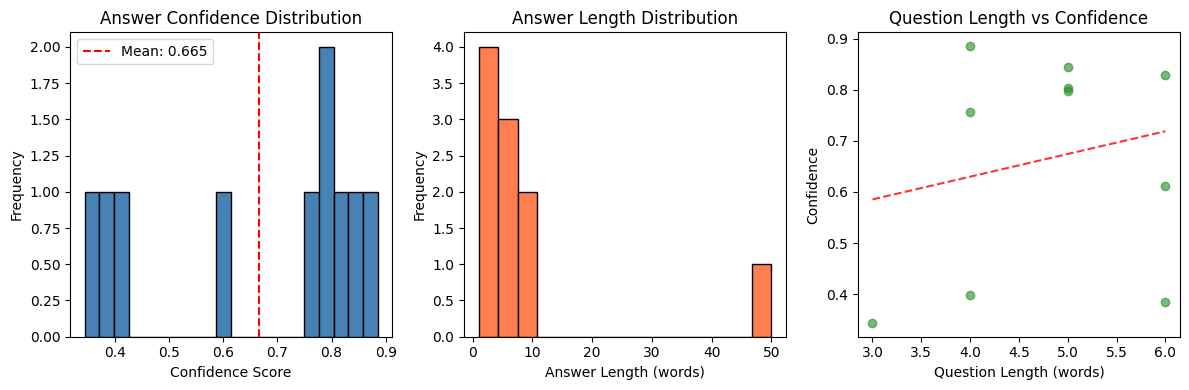


📈 Summary Statistics:
----------------------------------------
   Total queries processed: 10
   Average confidence: 0.6653
   Median confidence: 0.7769
   Std deviation: 0.2022
   Min confidence: 0.3438
   Max confidence: 0.8852
   Average answer length: 9.0 words

🏆 Best Answer (Highest Confidence):
   Q: What is machine learning?
   A: intussusception
   Confidence: 0.885

⚠️ Worst Answer (Lowest Confidence):
   Q: Explain reinforcement learning
   A: haines, ak. gold fever is in parker ' s blood. ever since he can remember, parker ' s beloved grandpa schnabel has been running the family gold mine, big nugget. since parker ' s feet could reach the pedals, he ' s been operating heavy machinery and learning the trade.
   Confidence: 0.344

✅ EVALUATION COMPLETE


In [60]:
# ============================================================================
# CELL 12: PERFORMANCE EVALUATION & VISUALIZATION
# ============================================================================
# PURPOSE: Evaluate system performance and create visualizations

print("\n" + "="*70)
print("📊 SYSTEM PERFORMANCE EVALUATION")
print("="*70)

# Analyze response times and confidence distribution
print("\n🔍 Analyzing system performance...")

# Use batch results for analysis
if 'batch_results' in dir() and len(batch_results) > 0:

    # 1. Confidence Distribution
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    confidences = [r['confidence'] for r in batch_results]
    plt.hist(confidences, bins=20, color='steelblue', edgecolor='black')
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Answer Confidence Distribution')
    plt.axvline(np.mean(confidences), color='red', linestyle='--', label=f'Mean: {np.mean(confidences):.3f}')
    plt.legend()

    # 2. Answer Length Distribution
    plt.subplot(1, 3, 2)
    answer_lengths = [len(r['answer'].split()) for r in batch_results]
    plt.hist(answer_lengths, bins=15, color='coral', edgecolor='black')
    plt.xlabel('Answer Length (words)')
    plt.ylabel('Frequency')
    plt.title('Answer Length Distribution')

    # 3. Question Length vs Confidence
    plt.subplot(1, 3, 3)
    question_lengths = [len(r['question'].split()) for r in batch_results]
    plt.scatter(question_lengths, confidences, alpha=0.6, color='forestgreen')
    plt.xlabel('Question Length (words)')
    plt.ylabel('Confidence')
    plt.title('Question Length vs Confidence')

    # Add trend line
    z = np.polyfit(question_lengths, confidences, 1)
    p = np.poly1d(z)
    plt.plot(sorted(question_lengths), p(sorted(question_lengths)), "r--", alpha=0.8)

    plt.tight_layout()
    plt.show()

    # 4. Summary Statistics Table
    print("\n📈 Summary Statistics:")
    print("-" * 40)
    print(f"   Total queries processed: {len(batch_results)}")
    print(f"   Average confidence: {np.mean(confidences):.4f}")
    print(f"   Median confidence: {np.median(confidences):.4f}")
    print(f"   Std deviation: {np.std(confidences):.4f}")
    print(f"   Min confidence: {np.min(confidences):.4f}")
    print(f"   Max confidence: {np.max(confidences):.4f}")
    print(f"   Average answer length: {np.mean(answer_lengths):.1f} words")

    # 5. Best and worst answers
    best_idx = np.argmax(confidences)
    worst_idx = np.argmin(confidences)

    print("\n🏆 Best Answer (Highest Confidence):")
    print(f"   Q: {batch_results[best_idx]['question']}")
    print(f"   A: {batch_results[best_idx]['answer']}")
    print(f"   Confidence: {confidences[best_idx]:.3f}")

    print("\n⚠️ Worst Answer (Lowest Confidence):")
    print(f"   Q: {batch_results[worst_idx]['question']}")
    print(f"   A: {batch_results[worst_idx]['answer']}")
    print(f"   Confidence: {confidences[worst_idx]:.3f}")

else:
    print("   Run batch questions in Cell 11 first to see performance metrics")

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE")
print("="*70)